# Outliers — Titanic Dataset

This notebook continues from the **Missing Values** notebook and uses:

`titanic_missing_values_handled.csv `

The previous step handled:
- `Age` → median imputation
- `Embarked` → mode imputation
- `Cabin` → removed

Now we will detect and understand outliers without blindly deleting valid observations.

## Learning Goals

- Understand what an outlier is
- Detect outliers with descriptive statistics and box plots
- Use the IQR method
- Inspect actual outlier records
- Understand why outliers should not automatically be removed
- Save the result for the next preprocessing step

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Load the Preprocessed Titanic Dataset

Place `titanic_missing_values_handled.csv` in the same folder as this notebook.

```text
03-Data-Preprocessing/
├── Missing-Values/
│   └── titanic_missing_values_handled.csv
└── Outliers/
    └── outliers.ipynb
```

If your file is in another location, change the path below.

In [ ]:
df = pd.read_csv("../dataset/titanic_missing_values_handled.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 3. Inspect the Dataset

In [ ]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 11)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 4. What Is an Outlier?

An **outlier** is an observation that is unusually far from the typical values in a dataset.

For Titanic, a very high `Fare` may be statistically unusual but still be a valid first-class ticket.

> An outlier is not automatically an error.

Always understand the feature and the domain before removing observations.

## 5. Select Numerical Features

We will examine:

- `Age`
- `Fare`
- `SibSp`
- `Parch`

We exclude `PassengerId` because it is an identifier, not a meaningful measurement.

We also exclude `Pclass` because it represents an ordered category rather than a continuous numerical measurement.

In [ ]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

df[numeric_features].describe()

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594
std,13.019697,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


## 6. Visualize Potential Outliers with Box Plots

C:\Users\Saubhagya\AppData\Local\Temp\ipykernel_13804\1686306365.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


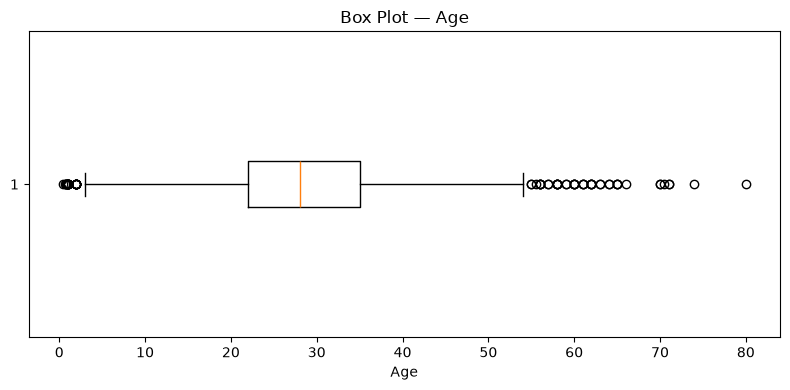

C:\Users\Saubhagya\AppData\Local\Temp\ipykernel_13804\1686306365.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


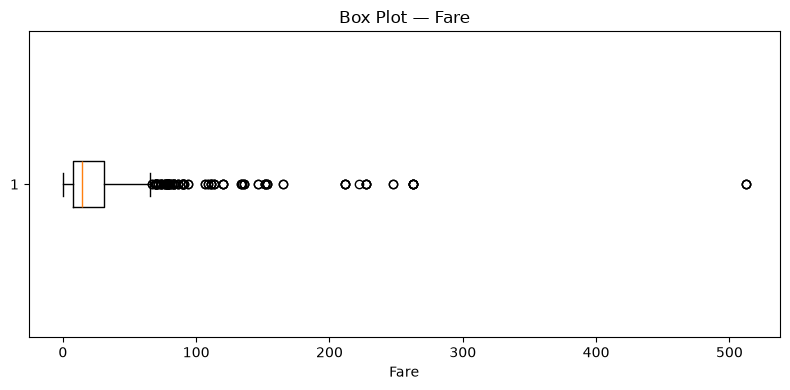

C:\Users\Saubhagya\AppData\Local\Temp\ipykernel_13804\1686306365.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


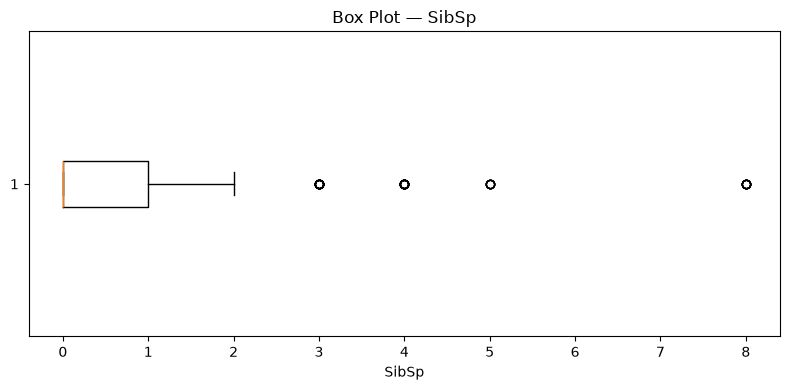

C:\Users\Saubhagya\AppData\Local\Temp\ipykernel_13804\1686306365.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


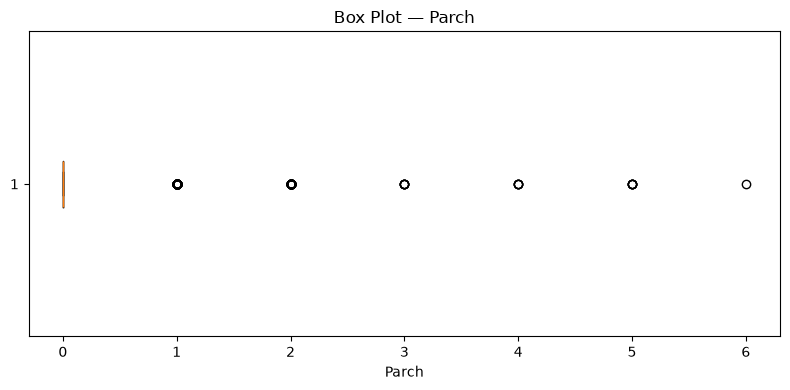

In [ ]:
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[feature], vert=False)
    plt.title(f"Box Plot — {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

## 7. IQR Method

The Interquartile Range is:

\[
IQR = Q3 - Q1
\]

Potential outlier boundaries are:

\[
Lower = Q1 - 1.5(IQR)
\]

\[
Upper = Q3 + 1.5(IQR)
\]

Values outside these boundaries are flagged as potential outliers.

In [ ]:
def iqr_outlier_summary(data, features):
    results = []

    for feature in features:
        q1 = data[feature].quantile(0.25)
        q3 = data[feature].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (data[feature] < lower) | (data[feature] > upper)

        results.append({
            "Feature": feature,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outlier Count": mask.sum(),
            "Outlier %": round(mask.mean() * 100, 2)
        })

    return pd.DataFrame(results)

outlier_summary = iqr_outlier_summary(df, numeric_features)
outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,22.0000,35.0,13.0000,2.500,54.5000,66,7.41
1,Fare,7.9104,31.0,23.0896,-26.724,65.6344,116,13.02
2,SibSp,0.0000,1.0,1.0000,-1.500,2.5000,46,5.16
3,Parch,0.0000,0.0,0.0000,0.000,0.0000,213,23.91


## 8. Inspect the Actual `Fare` Outliers

In [ ]:
feature = "Fare"

q1 = df[feature].quantile(0.25)
q3 = df[feature].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fare_outliers = df[
    (df[feature] < lower) | (df[feature] > upper)
]

fare_outliers[
    [feature, "Pclass", "Sex", "Age", "Survived"]
].sort_values(feature, ascending=False).head(20)

,Fare,Pclass,Sex,Age,Survived
258,512.3292,1,female,35.0,1
737,512.3292,1,male,35.0,1
679,512.3292,1,male,36.0,1
27,263.0000,1,male,19.0,0
341,263.0000,1,female,24.0,1
438,263.0000,1,male,64.0,0
88,263.0000,1,female,23.0,1
311,262.3750,1,female,18.0,1
742,262.3750,1,female,21.0,1
299,247.5208,1,female,50.0,1


## 9. Should We Remove These Outliers?

**No — not automatically.**

For example, a high Titanic fare may represent a genuine first-class passenger.

Possible strategies for outliers are:

1. Keep them
2. Remove them
3. Cap/Winsorize them
4. Transform the feature
5. Investigate whether they are data errors

For this notebook, we will **keep the observations** because the detected values can represent real passengers and the purpose is to learn the detection process.

## 10. Capping / Winsorization — Demonstration

Capping limits extreme values without deleting rows:

```python
df["Fare"] = df["Fare"].clip(lower, upper)
```

We will **not apply it** to the final Titanic dataset because changing valid fares without a clear modeling reason would unnecessarily alter the data.

## 11. Create the Dataset for the Next Step

In [ ]:
df_processed = df.copy()

print("Original shape:", df.shape)
print("Processed shape:", df_processed.shape)

Original shape: (891, 11)
Processed shape: (891, 11)


## 12. Verify the Dataset

In [ ]:
print("Remaining missing values:")
print(df_processed.isnull().sum())

print("\nShape:", df_processed.shape)

print("\nColumns:")
print(df_processed.columns.tolist())

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Shape: (891, 11)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


## 13. Save for the Encoding Step

The next stage is **Encoding**.

```text
titanic_missing_values_handled.csv
              ↓
            Outliers
              ↓
titanic_outliers_handled.csv
              ↓
           Encoding
```

In [ ]:
output_path = "../Dataset/titanic_outliers_handled.csv"

df_processed.to_csv(output_path, index=False)

print(f"Saved at:  {output_path}")

Saved: ../Dataset/titanic_outliers_handled.csv


## Key Takeaways

- Outliers are unusual observations, not automatically bad data.
- Box plots provide a quick visual check.
- The IQR method uses `Q1`, `Q3`, and `1.5 × IQR`.
- Always inspect actual observations before removing them.
- `PassengerId` should not be treated as a numerical feature.
- `Pclass` is an ordered category, so standard IQR analysis is not appropriate.
- For this Titanic dataset, we keep the detected outliers because many can represent valid passengers.

### Next

```text
Missing Values
      ↓
Outliers
      ↓
Encoding
      ↓
Scaling
      ↓
Feature Engineering
      ↓
ML-Ready Dataset
```